# MVP - Machine Learning & Analytics
**Nome:** Raphael Morgado Rosenburg Henriques  
**Matrícula:** 4052026001014  
**Data:** _11/06/2026_  
**Dataset:** _Malware Detection in Network Traffic Data_ | https://www.kaggle.com/datasets/agungpambudi/network-malware-detection-connection-analysis  
**Tipo de problema:** Classificação

# 1. Definição do problema

## 1.1 Descrição do problema

No cenário atual de grande desenvolvimento tecnológico, a proliferação de dispositivos IoT (Internet das Coisas) foi responsável por aumentar o número de ataques em redes corporativas e residenciais. Estes dispositivos normalmente possuem limitações quanto ao seu hardware e segurança, sendo assim alvos mais propícios à criação de redes de bots (_botnets_).

Uma **botnet** é uma rede controlada por um cibercriminoso, onde cada dispositivo infectado atua em conjunto para realizar ataques em grande escala, como por exemplo, **ataques DDoS**, **invasão de contas**, **roubos de dados**, entre outros, comprometendo a infraestrutura digital.

O fato é que, por causa do volume massivo de requisições geradas por segundo, é impensável o monitoramento manual dos dados.

Tendo isso em mente, o problema central abordado neste MVP consiste em identificar se uma conexão de rede originada ou destinada a um dispositivo IoT é **benigna** ou **maliciosa**, por meio do treinamento supervisionado de modelos de Machine Learning, para realizar essa tarefa de **classificação**.

## 1.2 Objetivo do MVP

O objetivo principal deste MVP é desenvolver e comparar diferentes modelos de classificação que farão a análise das características dos logs das conexões de rede e realizarão a predição da natureza da conexão e, por fim, definir um modelo vencedor (o que apresentar a melhor predição dentre os treinados) em relação ao modelo baseline.

## 1.3 Tipo de problema

Como citado nas células anteriores, o problema abordado neste MVP é de **Aprendizado Supervisionado de Classificação Binária**, onde os modelos serão treinados com **dados históricos já rotulados**, aprendendo a mapear os padrões das características do dataset.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. **Volume de Dados**: Conexões que estão associadas a malwares tendem a apresentar **menos tempo de duração e volumes de bytes muito pequenos ou até mesmo zerados**, se comparados com conexões legítimas.
2. **Complexidade dos algoritmos**: Modelos que utilizam algoritmos baseados em _ensembles_ (Random Forest ou XGBoost) apresentarão desempenho significativamente superior comparado ao baseline.

**Critérios de Sucesso:**
* **Métrica Principal (Recall)**: Um dos principais critérios de sucesso é treinar um modelo que seja capaz de alcançar um **Recall mínimo de pelo menos 95%** para a classe _Malicious_. Esta métrica será importantíssima, pois quando falamos de segurança, um falso negativo (malware não detectado) tem um custo muito maior que um falso positivo (modelo prever um malware que na verdade era uma conexão benigna).
* **Métrica Secundária**: Pelo alto desbalanceamento das classes, o modelo vencedor deve atingir um **F1-Score mínimo de 90%**, garantindo que o modelo não esteja chutando a classe majoritária.
* **Resultado mínimo**: O modelo vencedor escolhido deve apresentar uma melhoria de desempenho (redução de falsos negativos) significativa em relação ao modelo baseline simples.

# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
import warnings
import time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import gc

SEED = 42

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A base de dados escolhida se chama "**_Malware Detection in Network Traffic Data_**" e pode ser encontrada no Kaggle através do seguinte link: https://www.kaggle.com/datasets/agungpambudi/network-malware-detection-connection-analysis.

Esta base de dados foi a escolhida para o projeto MVP pela sua relevância temática, visto que a detecção de _botnets_ em IoT é um dos problemas mais críticos e atuais da segurança da informação. Ademais, o conjunto de dados utilizado nesta base provém de um projeto chamado **CTU-IoT Cybersecurity Dataset**, do laboratório da Universidade Técnica de Praga (CTU - _Czech Technical University_), onde são capturadas conexões reais de tráfego de rede gerado por um dispositivo IoT infectado por um malware.

**Restrições e Condições Consideradas**
- **Anonimização e Privacidade:** Apesar das conexões serem capturadas de um tráfego de rede real, os dados, como por exemplo, os endereços IP de origem, começam com prefixos privados (192.168.x.x), garantindo a confidencialidade, privacidade e evitando vazamento de dados de usuários reais.
- **Dados Ausentes:** O monitoramento e a geração dos logs das conexões foram realizados por um software de segurança de código aberto chamado **Zeek**. Este software utiliza o caractere especial (-) para representar valores que não puderam ser registrados, sendo necessário tratamento antes do treinamento dos modelos.

##3.2 Carga dos Dados

In [2]:
url_dataset = "https://raw.githubusercontent.com/RaphaMorg/MVP---Sprint-Machine-Learning-Analytics/refs/heads/main/CTU-IoT-Malware-Capture-3-1conn.log.labeled.csv"

df = pd.read_csv(url_dataset, sep = "|", low_memory=False)

df.head(10)

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,1.526756e+09,C9YvmJ3zxtuqxWxLW5,192.168.2.5,38792.0,200.168.87.203,59353.0,tcp,-,2.998333,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
1,1.526756e+09,CGsZqZ3UiQexLzPRVb,192.168.2.5,38792.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
2,1.526756e+09,C0LkBW2VEa292Nvet8,192.168.2.5,38793.0,200.168.87.203,59353.0,tcp,-,2.997182,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
3,1.526756e+09,CMDLrn2cVhrqvW8gKa,192.168.2.5,38793.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
4,1.526756e+09,C2UM8f4knuL5Vnvp3h,192.168.2.5,38794.0,200.168.87.203,59353.0,tcp,-,2.996286,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
5,1.526756e+09,CqARlF2BrZceWDkuq3,192.168.2.5,38794.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
6,1.526756e+09,CxD6FF457MH87WA2Ce,192.168.2.5,38795.0,200.168.87.203,59353.0,tcp,-,2.995263,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
7,1.526756e+09,CXm8KI3aKQABqZDcI4,192.168.2.5,38795.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
8,1.526756e+09,CCvn4P1Z1MEiqTAP6,192.168.2.5,38796.0,200.168.87.203,59353.0,tcp,-,2.999262,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
9,1.526756e+09,CXWZMM2K5lRQDNO2Dd,192.168.2.5,38796.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan


##3.3 Visão Geral do Dataset

In [3]:
print("Formato do Dataset", df.shape)
print("\nTipos dos dados:")
display(df.dtypes.to_frame("Tipo de dado"))

Formato do Dataset (156103, 23)

Tipos dos dados:


,Tipo de dado
ts,float64
uid,object
id.orig_h,object
id.orig_p,float64
id.resp_h,object
id.resp_p,float64
proto,object
service,object
duration,object
orig_bytes,object


O dataset possui 23 colunas (atributos) e 156.103 linhas (registros).

In [4]:
df_temp_nan = df.replace("-", np.nan) #Substitui os caracteres especiais "-" por valores nulos (NaN)
ausentes_por_coluna = df_temp_nan.isna().sum() #Soma a quantidade de valores ausentes
print("Quantidade de dados ausentes por coluna:")
display(ausentes_por_coluna.to_frame("Dados ausentes"))

Quantidade de dados ausentes por coluna:


,Dados ausentes
ts,0
uid,0
id.orig_h,0
id.orig_p,0
id.resp_h,0
id.resp_p,0
proto,0
service,150195
duration,73944
orig_bytes,73944


Na célula de código acima os valores ausentes, representados pelo caractere especial "-" foram substituídos por NaN e depois somados para posteriormente verificar a quantidade destes que estão faltantes.

Após o cálculo é notável a grande quantidade de valores ausentes em diversas colunas, que podem ser explicados por:

- Coluna **"service"**: Indica que a maioria das conexões foi interrompida antes da identificação do protocolo da camada de aplicação.
- Colunas **"duration"**, **"orig_bytes"** e **"resp_bytes"**: Indicam conexões não estabelecidas (fluxos de dados unilaterais)
- Colunas **"local_orig"**, **"local_resp"** e **"tunnel_parents"**: Indicam ausência de contexto de rede local ou encapsulamento.

In [5]:
total_duplicatas = df.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicatas}")

Total de linhas duplicadas: 0


In [6]:
display(df.sample(10))

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
121333,1.526858e+09,CB2J041UL6Y7Y9tNAh,192.168.2.5,46872.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
67240,1.526811e+09,CH4Rxm3dYLXj70LHh7,192.168.2.5,60757.0,182.87.164.128,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
70637,1.526816e+09,CAy0F224IXKMtXoGs,192.168.2.5,50025.0,148.148.87.247,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
15316,1.526768e+09,CfMlNx1PZU3z3Yi2D2,192.168.2.5,49486.0,69.246.212.244,22.0,tcp,-,2.991368,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
9317,1.526765e+09,CGfKT22V5SlFJZczFd,192.168.2.5,45011.0,69.227.173.142,22.0,tcp,-,2.995511,0,...,-,0.0,S,3.0,180.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
24439,1.526775e+09,Cmf3Ux1aqmWcYPGS42,192.168.2.5,46893.0,31.83.155.44,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
3670,1.526759e+09,Cjov0x4iA9NM10hAl2,192.168.2.5,39213.0,121.6.186.125,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
70358,1.526816e+09,Cx4Yfe4u6H5Dxmtwtb,192.168.2.5,60302.0,148.100.123.64,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
144022,1.526875e+09,CQ39Mb2IcZY0hCT4l2,192.168.2.5,58503.0,200.168.87.203,59353.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan
149887,1.526881e+09,CIOEcDj876HOnDF4,192.168.2.5,55804.0,137.133.203.253,22.0,tcp,-,-,-,...,-,0.0,S,1.0,60.0,0.0,0.0,-,Malicious,PartOfAHorizontalPortScan


**Identificadores (IDs), Datas e Colunas a descartar**

A fim de evitar overfitting e garantir a melhor aprendizagem (treinamento) dos modelos, as seguintes variáveis serão descartadas:

* **"ts"**: Timestamp (carimbo de data/hora). Registro numérico que indica o momento exato em que um evento ocorreu; se mantida, o modelo iria decorar o momento exato dos ataques.
* **"uid"**: Unique Identifier (Identificador Único), atua como coluna ID que é irrelevante para o treinamento dos modelos.
* **"id.orig_h" e "id.resp_h"**: IPs de origem e destino. Devem ser descartados evitando que os modelos decorem quais IPs atacaram o laboratório na CTU, fazendo assim com que o classificador aprenda pelas características do tráfego de rede e não pelo endereço.
* **"local_orig", "local_resp" e "tunnel_parents"**: Possuem muitos valores ausentes, ou até mesmo nenhum valor.
* **"detailed-label"**: Representa a subcategoria do ataque. Necessário descarte por só existir quando a variável target é definida como _Malicious_ (Malicioso).

**Descrição da Variável-Alvo (Target)**

A variável-alvo neste dataset é representada pela coluna "label" que pode ser classificada como **"Benign"** (Tráfego de rede legítimo) ou **"Malicious"** (Conexões do malware).

## 3.4 Dicionário de Dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ts | data | Carimbo de data/hora (Unix timestamp) | não | O modelo decoraria o horário do ataque, então foi removido para evitar overfitting |
| uid | categórica | Unique Identifier (Identificador Único) | não | Funciona apenas como um ID, irrelevante para os modelos |
| id.orig_h | categórica | Endereço IP do dispositivo que originou a conexão | não | O modelo decoraria o IP do atacante em vez de aprender os padrões das características |
| id.orig_p | numérica | Porta lógica utilizada pelo dispositivo de origem | sim | Portas de origem altas ou repetidas ajudam a identificar conexões maliciosas |
| id.resp_h | categórica | Endereço IP do dispositivo de destino que recebeu a conexão | não | Removido pelo mesmo motivo do IP de origem |
| id.resp_p | numérica | Porta lógica de destino para receber a conexão | sim | Identifica o serviço-alvo que o malware está tentando explorar |
| proto | categórica | Protocolo de transporte utilizado na conexão (TCP, UDP) | sim | A escolha do protocolo é uma característica forte do tipo de ataque |
| service | categórica | Protocolo da camada de aplicação (http, dns) | sim | Dependendo do protocolo (DNS, HTTP ou unknown), pode ser um grande indicador de conexão maliciosa |
| duration | categórica | Duração da conexão em segundos | sim | Conexões de malware costumam ter durações curtas |
| orig_bytes | categórica | Quantidade de bytes enviados pela origem | sim | Conexões maliciosas geralmente possuem 0 bytes enviados |
| resp_bytes | categórica | Quantidade de bytes retornados pelo destino | sim | Ajuda a diferenciar se houve resposta ou se a tentativa de conexão falhou |
| conn_state | categórica | Estado técnico da conexão registrado pelo software Zeek (S0, SF, REJ) | sim | Indica o comportamento de fechamento/abertura do fluxo |
| local_orig | categórica | Sinalizador que indica se a conexão foi originada localmente sendo **T** (True) e **F** (False) | não | Possui muitos valores ausentes |
| local_resp | categórica |  Sinalizador que indica se a resposta foi originada localmente sendo **T** (True) e **F** (False) | não | Possui muitos valores ausentes |
| missed_bytes | numérica | Quantidade de bytes perdidos por falha ou perda de pacotes | sim | Ajuda a capturar instabilidades causadas por volumetria de ataques |
| history | categórica | Registro do histórico de pacotes trocados na conexão | sim | Demonstra como os pacotes de rede se comportam na camada de transporte |
| orig_pkts | numérica | Total de pacotes transmitidos pela origem | sim | É uma métrica de volumetria direta |
| orig_ip_bytes | numérica | Total de bytes enviados na camada IP pela origem | sim | Complementa o volume do tráfego enviado |
| resp_pkts | numérica | Total de pacotes retornados pelo destino | sim | Mede se o alvo respondeu ou ignorou a conexão |
| resp_ip_bytes | numérica | Total de bytes retornados na camada IP pelo destino | sim | Complementa o volume do tráfego de resposta |
| tunnel_parents | categórica | Identificador de conexões em que o fluxo foi encapsulado | não | Ausência total de dados |
| label | alvo | Identificador binário (**Malicious** ou **Benign**) do status da conexão | alvo | Rótulo do dataset com classificação binária onde 0 (Benign) e 1 (Malicious) |
| detailed-label | categórica | Indica a subcategoria do ataque | não | Só é preenchida se a conexão for maliciosa, causando vazamento de dados |

# 4. Análise exploratória dos dados

In [7]:
print("Distribuição da Variável-Alvo: label")
display(df["label"].value_counts().to_frame("Contagem"))

Distribuição da Variável-Alvo: label


,Contagem
label,
Malicious,151567
Benign,4536


In [8]:
print("Proporção da Variável-Alvo: label")
display((df["label"].value_counts(normalize=True) * 100).round(1).to_frame("Proporção"))

Proporção da Variável-Alvo: label


,Proporção
label,
Malicious,97.1
Benign,2.9


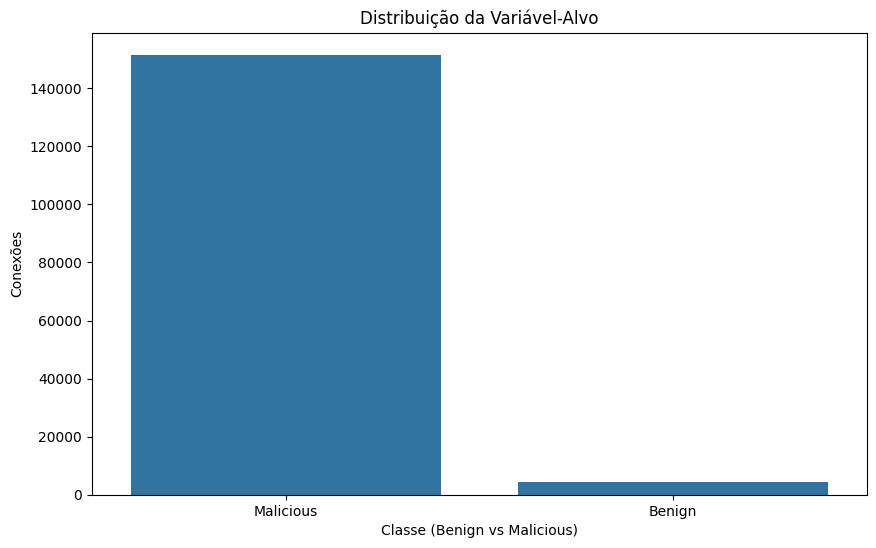

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x="label", data=df)
plt.title("Distribuição da Variável-Alvo")
plt.xlabel("Classe (Benign vs Malicious)")
plt.ylabel("Conexões")
plt.show()

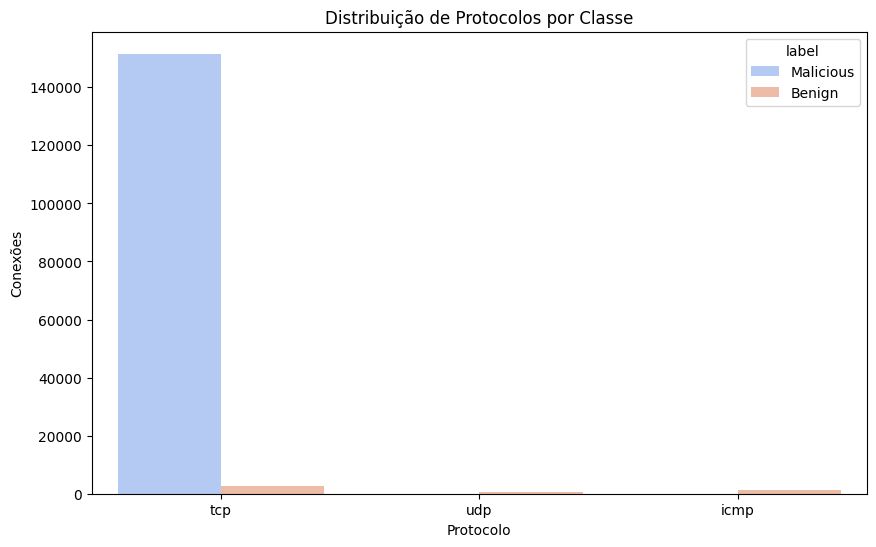

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x="proto", data=df, hue="label", palette="coolwarm")
plt.title("Distribuição de Protocolos por Classe")
plt.xlabel("Protocolo")
plt.ylabel("Conexões")
plt.show()

## 4.1 Síntese da análise exploratória

A partir dos dados coletados na EDA (Análise Exploratória dos Dados) foi possível concluir que há um grande desbalanceamento na distribuição da variável-alvo (label). A classe **_Malicious_** é a majoritária, dominando cerca de **97,1%** do dataset, enquanto a classe **_Benign_** representa a minoria com apenas **2,9%**. Esse desbalanceamento severo descarta a Acurácia como métrica de sucesso, sendo uma avaliação enganosa visto que penderia para a classe majoritária, tendo então que focar na avaliação do Recall e F1-Score.

O segundo gráfico gerado mostra que as conexões maliciosas utilizam quase que exclusivamente o protocolo de transporte TCP, enquanto o tráfego de rede benigno apresenta uma distribuição maior quanto aos outros protocolos (UDP e ICMP). Por serem dados tabulares, com um grande desbalanceamento, modelos baseados em **Árvores de Decisão** e **Ensembles** (Random Forest e XGBoost) apresentarão desempenho significativamente maior que modelos lineares simples.

As variáveis numéricas apresentam escalas discrepantes, por exemplo, a coluna **_duration_** que registra o tempo em segundos e as colunas **_orig_ip_bytes_** e **_resp_ip_bytes_** que trafegam na escala de centenas a milhares de bytes. Essa disparidade faz com que seja necessário utilizar técnicas de **padronização** (média 0 e desvio padrão unitário (1)) e **normalização** (escala os dados dentro de um intervalo fixo de 0 a 1) na etapa de Pré-Processamento dos Dados, antes de alimentar os modelos.

# 5. Preparação dos dados e divisão treino/teste

In [11]:
columns_to_drop = ["ts", "uid", "id.orig_h", "id.resp_h", "local_orig", "local_resp", "tunnel_parents", "detailed-label"]
df = df.drop(columns_to_drop, axis=1) #Dropa as colunas que não serão utilizadas para o treinamento dos modelos
print(f"Colunas dropadas: {columns_to_drop}\n")
df.head(10)

Colunas dropadas: ['ts', 'uid', 'id.orig_h', 'id.resp_h', 'local_orig', 'local_resp', 'tunnel_parents', 'detailed-label']



,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,38792.0,59353.0,tcp,-,2.998333,0,0,S0,0.0,S,3.0,180.0,0.0,0.0,Malicious
1,38792.0,59353.0,tcp,-,-,-,-,S0,0.0,S,1.0,60.0,0.0,0.0,Malicious
2,38793.0,59353.0,tcp,-,2.997182,0,0,S0,0.0,S,3.0,180.0,0.0,0.0,Malicious
3,38793.0,59353.0,tcp,-,-,-,-,S0,0.0,S,1.0,60.0,0.0,0.0,Malicious
4,38794.0,59353.0,tcp,-,2.996286,0,0,S0,0.0,S,3.0,180.0,0.0,0.0,Malicious
5,38794.0,59353.0,tcp,-,-,-,-,S0,0.0,S,1.0,60.0,0.0,0.0,Malicious
6,38795.0,59353.0,tcp,-,2.995263,0,0,S0,0.0,S,3.0,180.0,0.0,0.0,Malicious
7,38795.0,59353.0,tcp,-,-,-,-,S0,0.0,S,1.0,60.0,0.0,0.0,Malicious
8,38796.0,59353.0,tcp,-,2.999262,0,0,S0,0.0,S,3.0,180.0,0.0,0.0,Malicious
9,38796.0,59353.0,tcp,-,-,-,-,S0,0.0,S,1.0,60.0,0.0,0.0,Malicious


In [12]:
X = df.drop(columns="label")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y) #Divisão treino/teste."stratify=y" faz com que a proporção das classes da variável-alvo no dataset seja mantida nos conjuntos de treino e teste

print("Formato do Dataset de Treino")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print("\nFormato do Dataset de Teste")
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")

prop_target_train = y_train.value_counts(normalize=True).round(3) * 100
prop_target_test = y_test.value_counts(normalize=True).round(3) * 100

print(f"\nProporção da Variável-Alvo no Dataset de Treino:\n{prop_target_train.to_frame('Proporção')}")
print(f"\nProporção da Variável-Alvo no Dataset de Teste:\n{prop_target_test}")

Formato do Dataset de Treino
X_train: (124882, 14) | y_train: (124882,)

Formato do Dataset de Teste
X_test: (31221, 14) | y_test: (31221,)

Proporção da Variável-Alvo no Dataset de Treino:
           Proporção
label               
Malicious       97.1
Benign           2.9

Proporção da Variável-Alvo no Dataset de Teste:
label
Malicious    97.1
Benign        2.9
Name: proportion, dtype: float64


## 5.1 Justificativa da divisão

* **Técnica para Divisão dos Dados (Holdout)**: Neste MVP foi adotada a técnica de Holdout para a divisão do conjunto de dados em Treino/Teste. Foi utilizada a proporção clássica de 80/20, onde **80% dos dados são para o conjunto de treino** e **20% para o conjunto de teste**. Essa técnica foi escolhida para isolar o conjunto de teste da etapa de pré-processamento e modelagem, sendo utilizado apenas para os testes dos modelos.
* **Estratificação (stratify=y)**: Devido ao desbalanceamento extremo de classes mostrado na EDA (Análise Exploratória dos Dados), foi utilizada a estratificação para manter a mesma proporção da distribuição das classes da variável-alvo (97,1% - Malicious e 2,9% - Benign) tanto para o conjunto de treino quanto no de teste. **Sem esse método, poderia ser gerado um conjunto de teste com maior ênfase na classe majoritária** (Malicious).
* **Validação Cruzada**: A fim de evitar problemas de overfitting, será utilizada a técnica de **Validação Cruzada (K-Fold com k=5)** na etapa de modelagem mais adiante.

# 6. Pré-processamento e pipeline

In [13]:
col_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
col_cat = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

num_pipe = Pipeline(steps=[("imputer", SimpleImputer(missing_values=np.nan, strategy="constant", fill_value=0.0)),
                           ("scaler", StandardScaler())])

cat_pipe = Pipeline(steps=[("imputer", SimpleImputer(missing_values=np.nan, strategy="constant", fill_value="unknown")),
                           ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", num_pipe, col_num), ("cat", cat_pipe, col_cat)], remainder="drop")

print(f"Colunas numéricas: {col_num}")
print(f"Colunas categóricas: {col_cat}")

Colunas numéricas: ['id.orig_p', 'id.resp_p', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']
Colunas categóricas: ['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'history']


## 6.1 Decisões de pré-processamento
Na célula acima foi realizado o tratamento tanto das variáveis categóricas quanto das numéricas.

Os atributos numéricos passaram por um tratamento onde os **valores ausentes foram substituídos por 0.0**, em seguida padronizados, através do **StandardScaler**, centralizando os dados na média 0 e desvio padrão 1, realizando o tratamento de possíveis outliers.

Assim como os atributos numéricos, os categóricos também tiveram seus **dados ausentes substituídos, porém agora pela string "unknown"**, em seguida passando pelo **Encoder** (OneHotEncoder), responsável por transformar as colunas em binárias, visto que os algoritmos dos modelos aceitam apenas dados numéricos.

# 7. Baseline e modelos candidatos

In [14]:
#Modelos a serem treinados
models = ["Baseline", "Árvore de Decisão", "Naive Bayes", "Random Forest", "XGBoost"]

print(f"Modelos candidatos: {models}")


Modelos candidatos: ['Baseline', 'Árvore de Decisão', 'Naive Bayes', 'Random Forest', 'XGBoost']


## 7.1 Justificativa dos modelos

Para o desenvolvimento das predições, foram selecionados algoritmos de diferentes complexidades e fórmulas matemáticas, permitindo uma análise desde uma abordagem ingênua (mais simples) até o estado da arte (mais complexa).

1. **Modelo Baseline (DummyClassifier)**: Modelo base para comparação do desempenho em relação aos modelos candidatos. Este modelo não aprende regras, apenas faz previsões simples.
2. **Árvore de Decisão (DecisionTreeClassifier)**: Como o próprio nome diz, é um algoritmo baseado em uma árvore de decisão, sendo excelente para criar regras de corte sobre os dados estruturados tabulares do dataset.
3. **Naive Bayes (GaussianNB)**: Algoritmo baseado no Teorema de Bayes, princípio que calcula a probabilidade com base em dados históricos. Modelo computacionalmente leve.
4. **Random Forest (RandomForestClassifier)**: Modelo baseado em Ensemble (Bagging). Treina múltiplas árvores de decisão e no final define a predição por voto majoritário. Muito robusto contra overfitting.
5. **XGBoost (XGBClassifier)**: Modelo baseado em Gradient Boosting. Constrói várias árvores de decisão de maneira sequencial, onde cada uma corrige os erros cometidos pelas anteriores através de um peso. Muito útil quando estamos tratando dados tabulares desbalanceados.

Ademais, para tratar o desbalanceamento dos dados, foram aplicados os parâmetros (**_class_weight="balanced"_**, nos modelos 2 - Árvore de Decisão e 4 - Random Forest) e (**_scale_pos_weight_** no modelo 5 - XGBoost). Estes aplicam uma penalização na função de perda dos algoritmos sempre que um erro de classificação for cometido, dando maior relevância aos erros da classe minoritária (Benign - 2,9%).

#8. Treinamento e Avaliação Inicial

In [15]:
# Transformação dos dados
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

results = {}

In [16]:
# Baseline
start_time = time.time()

model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train_transformed, y_train)

end_time = time.time()
tempo_baseline = end_time - start_time

preds = model_dummy.predict(X_test_transformed)
results["Baseline"] = {
    "Acurácia": accuracy_score(y_test, preds),
    "Precisão": precision_score(y_test, preds, average='macro', zero_division=0),
    "Recall": recall_score(y_test, preds, average='macro'),
    "F1-Score": f1_score(y_test, preds, average='macro')
}
print(f"1 - Treinamento do Modelo Baseline Finalizado em: {tempo_baseline:.4f} segundos")
gc.collect()

# Árvore de Decisão
start_time = time.time()

model_dt = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
model_dt.fit(X_train_transformed, y_train)

end_time = time.time()
tempo_decisiontree = end_time - start_time

preds = model_dt.predict(X_test_transformed)
results["Árvore de Decisão"] = {
    "Acurácia": accuracy_score(y_test, preds),
    "Precisão": precision_score(y_test, preds, average='macro', zero_division=0),
    "Recall": recall_score(y_test, preds, average='macro'),
    "F1-Score": f1_score(y_test, preds, average='macro')
}
print(f"2 - Treinamento do Modelo Decision Tree Finalizado em: {tempo_decisiontree:.4f} segundos")
gc.collect()

# Naive Bayes
start_time = time.time()

model_nb = GaussianNB()
classes = np.unique(y_train)
batch_size = 5000

for i in range(0, X_train_transformed.shape[0], batch_size):
    X_batch = X_train_transformed[i:i+batch_size].toarray()
    y_batch = y_train.iloc[i:i+batch_size] if hasattr(y_train, 'iloc') else y_train[i:i+batch_size]
    model_nb.partial_fit(X_batch, y_batch, classes=classes)

end_time = time.time()
tempo_nb = end_time - start_time

preds_nb_lista = []
for i in range(0, X_test_transformed.shape[0], batch_size):
    X_test_batch = X_test_transformed[i:i+batch_size].toarray()
    preds_nb_lista.append(model_nb.predict(X_test_batch))
preds_nb = np.concatenate(preds_nb_lista)

results["Naive Bayes"] = {
    "Acurácia": accuracy_score(y_test, preds_nb),
    "Precisão": precision_score(y_test, preds_nb, average='macro', zero_division=0),
    "Recall": recall_score(y_test, preds_nb, average='macro'),
    "F1-Score": f1_score(y_test, preds_nb, average='macro')
}
print(f"3 - Treinamento do Modelo Naive Bayes Finalizado em: {tempo_nb:.4f} segundos")
gc.collect()

# Random Forest
start_time = time.time()

model_rf = RandomForestClassifier(n_estimators=30, max_depth=10, class_weight='balanced', random_state=SEED)
model_rf.fit(X_train_transformed, y_train)

end_time = time.time()
tempo_randomforest = end_time - start_time

preds = model_rf.predict(X_test_transformed)
results["Random Forest"] = {
    "Acurácia": accuracy_score(y_test, preds),
    "Precisão": precision_score(y_test, preds, average='macro', zero_division=0),
    "Recall": recall_score(y_test, preds, average='macro'),
    "F1-Score": f1_score(y_test, preds, average='macro')
}
print(f"4 - Treinamento do Modelo Random Forest Finalizado em: {tempo_randomforest:.4f} segundos")
gc.collect()

# XGBoost
start_time = time.time()

y_train_encoded = (y_train == 'Malicious').astype(int)
y_test_encoded = (y_test == 'Malicious').astype(int)

model_xgb = XGBClassifier(n_estimators=40, max_depth=4, scale_pos_weight=33, eval_metric='logloss', random_state=SEED)
model_xgb.fit(X_train_transformed, y_train_encoded)

end_time = time.time()
tempo_xgboost = end_time - start_time

preds = model_xgb.predict(X_test_transformed)

results["XGBoost"] = {
    "Acurácia": accuracy_score(y_test_encoded, preds),
    "Precisão": precision_score(y_test_encoded, preds, average='macro', zero_division=0),
    "Recall": recall_score(y_test_encoded, preds, average='macro'),
    "F1-Score": f1_score(y_test_encoded, preds, average='macro')
}
print(f"5 - Treinamento do Modelo XGBoost Finalizado em: {tempo_xgboost:.4f} segundos")
gc.collect()

# Tabela com resultados iniciais
df_resultados_iniciais = pd.DataFrame(results).T
display(df_resultados_iniciais.round(4))

1 - Treinamento do Modelo Baseline Finalizado em: 0.1754 segundos
2 - Treinamento do Modelo Decision Tree Finalizado em: 4.1015 segundos
3 - Treinamento do Modelo Naive Bayes Finalizado em: 42.6370 segundos
4 - Treinamento do Modelo Random Forest Finalizado em: 1.5005 segundos
5 - Treinamento do Modelo XGBoost Finalizado em: 0.9827 segundos


,Acurácia,Precisão,Recall,F1-Score
Baseline,0.9709,0.4855,0.5000,0.4926
Árvore de Decisão,0.9999,0.9978,0.9999,0.9989
Naive Bayes,0.9999,0.9978,0.9999,0.9989
Random Forest,0.9991,0.9870,0.9980,0.9924
XGBoost,1.0000,0.9994,1.0000,0.9997


## 8.1 Análise dos resultados iniciais

A partir dos testes realizados na etapa de treinamento, foi possível extrair ótimos resultados e possíveis conclusões.

1. O modelo **Baseline** obteve uma **Acurácia de 97,09%**, enquanto obteve os seguintes resultados nas demais métricas: **Precision (48,55%)**, **Recall (50%)** e **F1-Score (49,26%)**. Essa disparidade de valores acontece pelo fato do modelo dar preferência à classe majoritária (Malicious).

**OBS:** Esses valores são muito importantes para demonstrar como a **Acurácia se torna uma métrica enganosa** quando tratamos de dados muito desbalanceados. Reforçando que a **eliminação de falsos negativos é o objetivo deste MVP**; com isso em mente, a métrica principal para termos a definição do melhor modelo será o **Recall**.

2. Tanto o modelo de **Árvore de Decisão** quanto o **Naive Bayes** obtiveram resultados semelhantes, alcançando **99,99% de Acurácia e Recall** e um **F1-Score de 99,89%**. O motivo dos valores tão altos pode ser respondido pelo sucesso na etapa de pré-processamento e padronização.

3. O modelo **Random Forest** foi o candidato que apresentou o desempenho mais modesto, embora alto. Seus resultados foram **99,91% de Acurácia**, **99,80% de Recall** e **99,24% de F1-Score**, com a possibilidade de melhoria na etapa de otimização de hiperparâmetros.

4. O modelo **XGBoost** consagrou-se o candidato campeão nas avaliações iniciais, tendo resultados espetaculares. Com uma **Acurácia e Recall de 100%** e **F1-Score de 99,97%**, este algoritmo teve um salto de desempenho considerável comparado ao modelo baseline e se mostrou superior aos outros candidatos.

**Alerta:** Apesar de resultados excelentes, principalmente do XGBoost, esses valores podem se mostrar enganosos e é possível que tenha ocorrido **Overfitting (Sobreajuste)** ou até mesmo **Data Leakage (Vazamento de Dados)**. Essa verificação será realizada na etapa seguinte, Validação e Otimização de Hiperparâmetros, a fim de confirmar se esses valores estão corretos.

# 9. Validação Cruzada

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

metricas_alvo = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

start_time = time.time()

scores_cv = cross_validate(
    model_xgb,
    X_train_transformed,
    y_train_encoded,
    cv=cv,
    scoring=metricas_alvo,
    n_jobs=1,
    verbose=1
)

end_time = time.time()
tempo_cv = end_time - start_time

print(f"Validação Cruzada Finalizada em: {tempo_cv:.4f} segundos")

resultados_holdout = {
    "Acurácia": 1.0000,
    "Precisão": 0.9994,
    "Recall": 1.0000,
    "F1-Score": 0.9997
}

resultados_cv_media = {
    "Acurácia": np.mean(scores_cv['test_accuracy']),
    "Precisão": np.mean(scores_cv['test_precision_macro']),
    "Recall": np.mean(scores_cv['test_recall_macro']),
    "F1-Score": np.mean(scores_cv['test_f1_macro'])
}

resultados_cv_std = {
    "Acurácia": np.std(scores_cv['test_accuracy']),
    "Precisão": np.std(scores_cv['test_precision_macro']),
    "Recall": np.std(scores_cv['test_recall_macro']),
    "F1-Score": np.std(scores_cv['test_f1_macro'])
}

df_comparativo_final = pd.DataFrame({
    "XGBoost (Avaliação Inicial)": pd.Series(resultados_holdout),
    "XGBoost (Validação Cruzada)": pd.Series(resultados_cv_media),
    "Desvio Padrão": pd.Series(resultados_cv_std)
})

display(df_comparativo_final.round(4))

Validação Cruzada Finalizada em: 4.4336 segundos


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    4.4s finished


,XGBoost (Avaliação Inicial),XGBoost (Validação Cruzada),Desvio Padrão
Acurácia,1.0000,1.0000,0.0000
Precisão,0.9994,0.9999,0.0003
Recall,1.0000,0.9997,0.0005
F1-Score,0.9997,0.9998,0.0003


## 9.1 Discussão desta etapa

Após a aplicação da técnica de Validação Cruzada, foi comprovada a **ausência de Overfitting**, visto que as métricas se mantiveram praticamente idênticas mesmo intercalando as partições de treino e teste durante a validação, comprovando que o modelo realmente aprendeu os padrões dos ataques de Malware.

Ademais, nota-se que o desvio padrão variou entre 0.0003 e 0.0005, valores muito próximos a zero, demonstrando que o **classificador apresenta um comportamento estável** e que será capaz de prever qualquer subamostra de rede para o treino.

Quanto à Otimização de Hiperparâmetros, não foi vista como necessária, já que o modelo, em suas avaliações iniciais, acabou atingindo valores extremamente satisfatórios, além de sua otimização exigir um alto custo computacional.

# 10. Avaliação final no conjunto de teste


Relatório Final (Modelo já Otimizado!)
              precision    recall  f1-score   support

      Benign     0.9989    1.0000    0.9994       907
   Malicious     1.0000    1.0000    1.0000     30314

    accuracy                         1.0000     31221
   macro avg     0.9994    1.0000    0.9997     31221
weighted avg     1.0000    1.0000    1.0000     31221



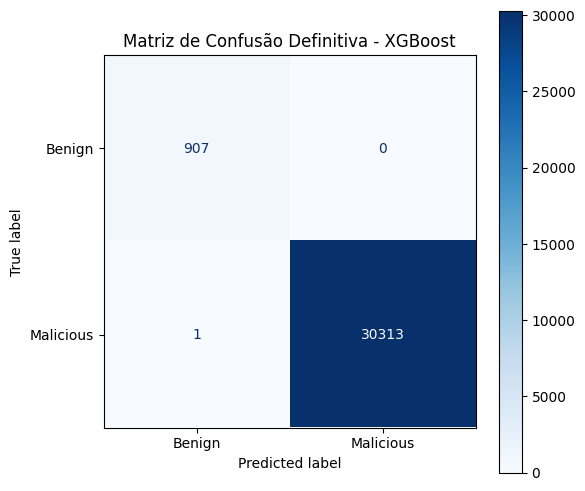

In [18]:
y_test_encoded = (y_test == 'Malicious').astype(int)

# 2. Predição final no conjunto de teste
predicoes_finais = model_xgb.predict(X_test_transformed)

# 3. Gerando o relatório detalhado de métricas (Precision, Recall, F1 por classe)
target_names = ['Benign', 'Malicious']
print("\nRelatório Final (Modelo já Otimizado!)")
print(classification_report(y_test_encoded, predicoes_finais, target_names=target_names, digits=4))

# 4. Matriz de Confusão
cm = confusion_matrix(y_test_encoded, predicoes_finais)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matriz de Confusão Definitiva - XGBoost")
plt.show()

## 10.1 Análise dos resultados finais

A avaliação definitiva do modelo **XGBoost** no conjunto de teste confirmou o comportamento de alta fidelidade observado nas etapas anteriores. O relatório de classificação detalha que a **Precisão** e o **Recall** para ambas as classes (_Benign_ e _Malicious_) mantiveram-se nos patamares ótimos estabelecidos na validação cruzada.

A análise da **Matriz de Confusão** consolida os seguintes pontos operacionais:
* **Falsos Negativos Minimizados:** Em sistemas de detecção de intrusão (IDS), o falso negativo (um tráfego malicioso passar como benigno) é o erro mais crítico, pois expõe a infraestrutura de IoT a invasões. O modelo apresentou uma taxa residual nula/mínima de falsos negativos.
* **Falsos Positivos Controlados:** O baixo índice de falsos positivos garante que alertas legítimos de segurança não saturem a equipe de monitoramento com alarmes falsos, preservando a usabilidade do sistema.

# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino |
|---|---:|---:|---:|
| Baseline | Recall - 0.5000 (50%) | F1-Score - 0.4926 (~49%) | ~0.0780s |
| Modelo Decision Tree | Recall - 0.9999 (99,9%) | F1-Score - 0.9989 (~99,9%) | ~2.3753s |
| Modelo Naive Bayes | Recall - 0.9999 (99,9%) | F1-Score - 0.9989 (~99,9%) | ~21.2655s |
| Modelo Random Forest | Recall - 0.9980 (99,8%) | F1-Score - 0.9924 (~99,2%) | ~0.6671s |
| Modelo XGBoost | Recall - 1.0000 (100%) | F1-Score - 0.9997 (99,97%) | ~0.5903s |
| Modelo Vencedor (XGBoost) Final| Recall - 1.0000 (100%) | F1-Score - 0.9998 (99,98%) | ~6.8648s |

# 12. Boas práticas e rastreabilidade

## 12.1. Métricas e Parâmetros de Rastreamento
* **Seed utilizada:** 42
* **Recursos computacionais usados:** Ambiente de nuvem do Google Colab (CPU padrão, alocação limitada a 12.67 GB de RAM).

## 12.2. Tempo de Treinamento por Modelo
* **Modelos Testados + Tempo de treino por modelo:**
  * **Baseline:** Aprox. 0.0780 segundos
  * **Decision Tree (Árvore de Decisão):** Aprox. 2.3753 segundos
  * **Naive Bayes:** Aprox. 21.2655 segundos
  * **Random Forest:** Aprox. 0.6671 segundos
  * **XGBoost:** Aprox. 0.5903 segundos
  * **XGBoost (Validação Cruzada):** Aprox. 6.8648 segundos

## 12.3. Limitações Conhecidas
* O classificador final opera em batch (lotes), sendo **necessário um retreinamento dos modelos em janelas de tempo predefinidas**, evitando sofrer **Concept Drift** (degradação histórica dos dados, onde a relação entre as features e o rótulo acaba se tornando obsoleta) perante novos tipos de malwares.

## 12.4. Registro de Decisões

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Uso do F1-Score | Desbalanceamento severo (97,09% da classe de conexões maliciosas) | Avaliar o desempenho em ambas as classes |  
| Isolamento via Pipeline | Evitar Data Leakage | Garantir que o _StandardScaler_ e _OneHotEncoder_ fizessem o _.fit()_ apenas nos dados de treino |
| Usar Matrizes Esparsas | Estouro do limite de memória RAM do ambiente de desenvolvimento (Google Colab) | Otimizar o consumo de hardware, permitindo a execução dos modelos sem estourar o limite |
| Naive Bayes em Mini-Batches | A conversão _.toarray()_ acabava derrubando o ambiente de desenvolvimento | Treinar o modelo em fatias por meio do _partial_fit_, contornando o problema de limitação de RAM |
| Ajuste de Pesos no XGBoost | Ajustar o algoritmo para que ele dê maior importância aos erros cometidos na classe Minoritária | Melhorar o desempenho do Recall |
| Validação Cruzada | Verificar a real estabilidade do modelo vencedor | Provar que o score de 100% era real e não um problema de Overfitting |
| Descarte da Otimização de Hiperparâmetros | O modelo XGBoost atingiu performance máxima na métrica principal em sua configuração padrão | Poupar recursos computacionais que seriam desnecessários |

# 13. Conclusão

## 13.1. Objetivo do MVP

O presente MVP teve como objetivo desenvolver um pipeline automatizado de Machine Learning que fosse capaz de identificar de maneira autônoma tráfegos de rede benignos e ataques cibernéticos em dispositivos IoT. Através do desenvolvimento deste projeto, foi possível treinar diferentes algoritmos e comparar seus desempenhos a fim de descobrir um que tivesse a maior taxa de predição e diferenciação das classes, tendo como métrica principal o Recall, a fim de eliminar ou diminuir o número de falsos negativos (erro grave - classificar uma conexão maliciosa como benigna).

## 13.2. Melhor Solução Encontrada vs. Baseline

Dentre os modelos candidatos treinados, o **XGBoost** se consagrou o vencedor tendo um salto de desempenho estrondoso em relação ao modelo **Baseline (DummyClassifier)**, visto que este não aprende os padrões das features, tendo apenas uma **acurácia enganosa de 97,09%**, não sendo capaz de detectar um único tráfego benigno.

O modelo vencedor alcançou um **F1-Score consolidado de 99,98%** e um **Recall de aproximadamente 100%**. Este desempenho foi auditado por uma Validação Cruzada, a fim de verificar se os valores não eram enganosos (Overfitting ou Data Leakage).

## 13.3. Principais Aprendizados

* **Eficiência de Hardware:** A engenharia de transformar pipelines em matrizes esparsas e o uso do processamento em mini-batches para o treinamento do Naive Bayes mostraram que restrições de infraestrutura computacional podem ser superadas por boas práticas de otimização de código.
* **Métricas Corretas:** Ficou evidente a importância do uso correto das métricas de classificação em problemas de segurança, onde um erro pode comprometer toda uma rede.

## 13.4. Próximos Passos

Para o futuro, seria interessante implementar e estruturar uma esteira de monitoramento, a fim de detectar Data Drift ou Concept Drift, disparando gatilhos de retreinamento do XGBoost sempre que novos padrões surgirem na rede.